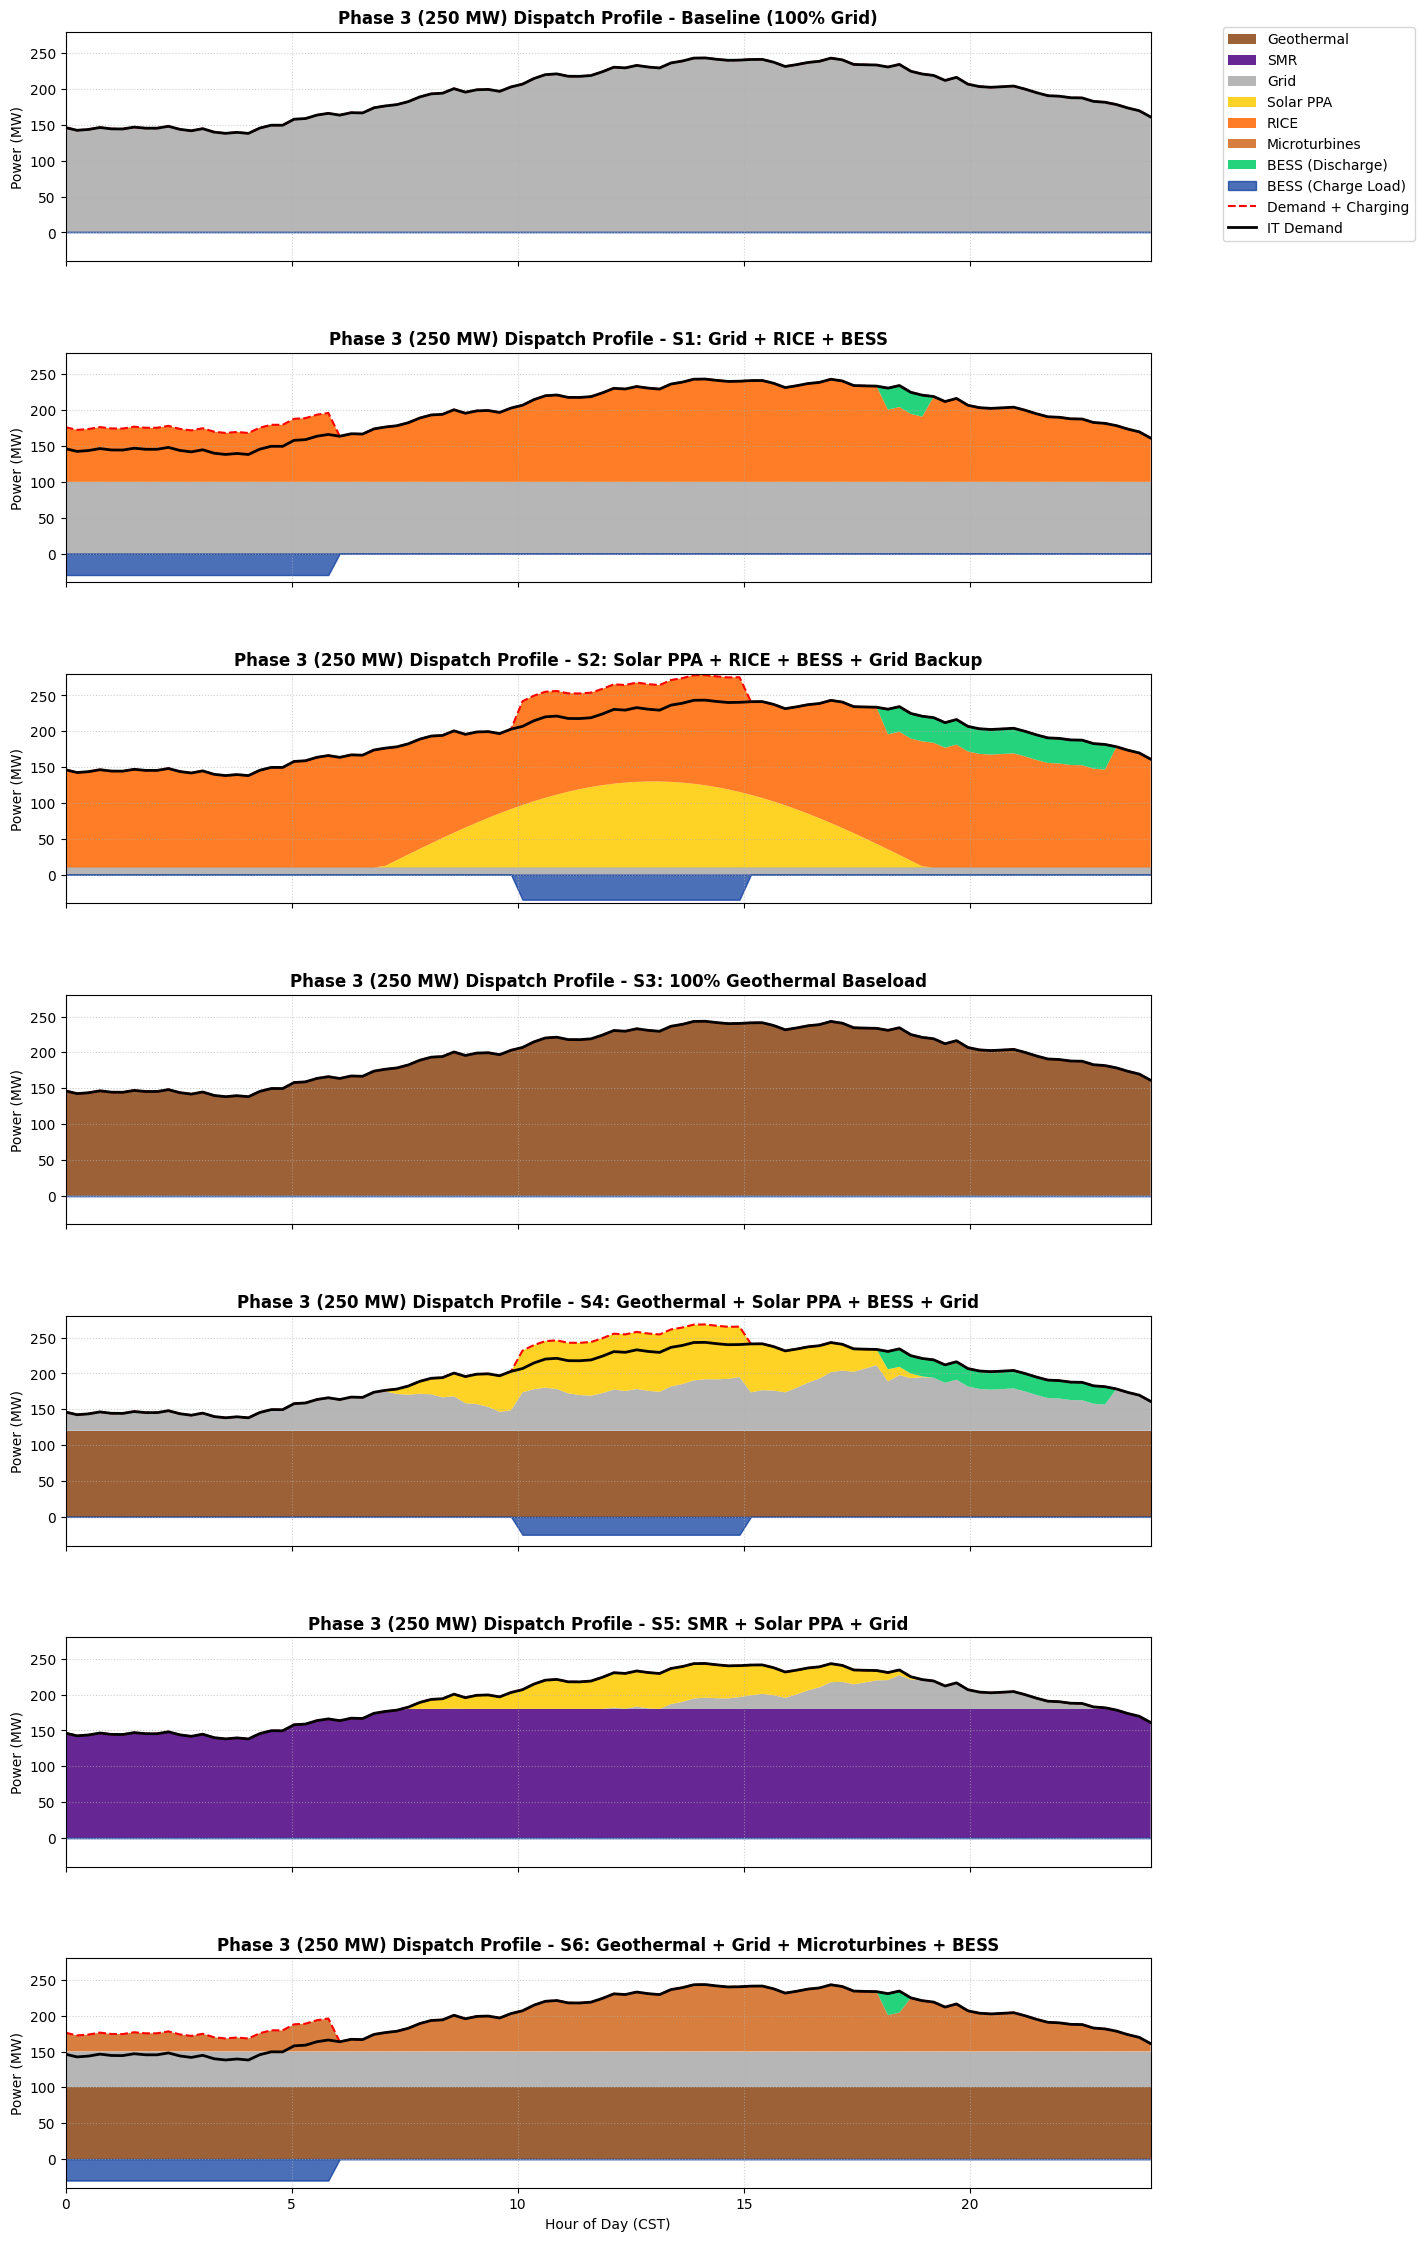

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP & HIGH USAGE DEMAND GENERATION
# ==========================================
np.random.seed(42)

TIME_STEPS = 96 # 15-minute intervals over 24 hours
time_hours = np.linspace(0, 24, TIME_STEPS)
MAX_POWER = 250 # MW for Phase 3

# High Usage (Spike) Base Curve: Sustained heavy daytime load
mean_u = 0.7 + 0.25 * np.sin(np.pi * (time_hours - 8) / 14)

# Autocorrelated Stochastic Noise
noise = np.random.normal(0, 0.05, TIME_STEPS)
smoothed_noise = pd.Series(noise).rolling(window=4, min_periods=1).mean().values
u_sim = np.clip(mean_u + smoothed_noise, 0.1, 1.0)

# Convert Utilization to MW (factoring in Idle Load and PUE)
PUE = 1.2
IDLE_FRACTION = 0.20
max_it_power = MAX_POWER / PUE
base_it_power = max_it_power * IDLE_FRACTION

demand_mw = (base_it_power + (max_it_power - base_it_power) * u_sim) * PUE
demand_mw = np.clip(demand_mw, 0, MAX_POWER) # Hard cap at facility limit

# Helper: Solar PPA Generation Curve (Daylight hours only)
solar_curve = np.zeros(TIME_STEPS)
daylight = (time_hours >= 7) & (time_hours <= 19)
solar_curve[daylight] = np.sin(np.pi * (time_hours[daylight] - 7) / 12) # Peaks at 1:00 PM

# Helper: Time Windows for Battery Operations
charging_hours_night = (time_hours >= 0) & (time_hours <= 6)
charging_hours_solar = (time_hours >= 10) & (time_hours <= 15)
evening_peak = (time_hours >= 18) & (time_hours <= 23)

# ==========================================
# 2. DISPATCH LOGIC FOR SCENARIOS
# ==========================================
dispatch_data = {}

# Baseline: 100% Grid
dispatch_data['Baseline (100% Grid)'] = {
    'Grid': demand_mw, 'RICE': np.zeros(TIME_STEPS), 'Solar PPA': np.zeros(TIME_STEPS),
    'Geothermal': np.zeros(TIME_STEPS), 'SMR': np.zeros(TIME_STEPS),
    'Microturbines': np.zeros(TIME_STEPS), 'BESS (Discharge)': np.zeros(TIME_STEPS),
    'BESS (Charge)': np.zeros(TIME_STEPS)
}

# Scenario 1: Grid (100 MW anchor) + RICE + BESS
s1_bess_charge = np.where(charging_hours_night, 30, 0) # Charge 30MW off-peak using RICE/Grid
s1_eff_demand = demand_mw + s1_bess_charge
s1_grid = np.minimum(s1_eff_demand, 100)
s1_remainder = s1_eff_demand - s1_grid
s1_bess_discharge = np.where(evening_peak & (demand_mw > 220), 30, 0) # Discharge during top peaks
s1_rice = s1_remainder - s1_bess_discharge

dispatch_data['S1: Grid + RICE + BESS'] = {
    'Grid': s1_grid, 'RICE': s1_rice, 'BESS (Discharge)': s1_bess_discharge,
    'Solar PPA': np.zeros(TIME_STEPS), 'Geothermal': np.zeros(TIME_STEPS),
    'SMR': np.zeros(TIME_STEPS), 'Microturbines': np.zeros(TIME_STEPS),
    'BESS (Charge)': s1_bess_charge
}

# Scenario 2: Solar PPA + RICE + BESS + Grid Backup (10 MW max)
s2_solar_gen = solar_curve * 120
s2_bess_charge = np.where(charging_hours_solar, 35, 0) # Charge during peak solar
s2_eff_demand = demand_mw + s2_bess_charge
s2_solar_used = np.minimum(s2_eff_demand, s2_solar_gen)
s2_grid = np.minimum(s2_eff_demand - s2_solar_used, 10)
s2_remainder = s2_eff_demand - s2_solar_used - s2_grid
s2_bess_discharge = np.where(evening_peak & (s2_remainder > 150), 35, 0)
s2_rice = np.maximum(s2_remainder - s2_bess_discharge, 0)

dispatch_data['S2: Solar PPA + RICE + BESS + Grid Backup'] = {
    'Grid': s2_grid, 'RICE': s2_rice, 'BESS (Discharge)': s2_bess_discharge, 'Solar PPA': s2_solar_used,
    'Geothermal': np.zeros(TIME_STEPS), 'SMR': np.zeros(TIME_STEPS), 'Microturbines': np.zeros(TIME_STEPS),
    'BESS (Charge)': s2_bess_charge
}

# Scenario 3: 100% Geothermal Transition
dispatch_data['S3: 100% Geothermal Baseload'] = {
    'Grid': np.zeros(TIME_STEPS), 'RICE': np.zeros(TIME_STEPS), 'BESS (Discharge)': np.zeros(TIME_STEPS),
    'Solar PPA': np.zeros(TIME_STEPS), 'Geothermal': demand_mw, 'SMR': np.zeros(TIME_STEPS), 'Microturbines': np.zeros(TIME_STEPS),
    'BESS (Charge)': np.zeros(TIME_STEPS)
}

# Scenario 4: Geothermal (120 MW) + Solar PPA (80 MW) + BESS + Grid
s4_geo = np.minimum(demand_mw, 120)
s4_solar_gen = solar_curve * 80
s4_bess_charge = np.where(charging_hours_solar, 25, 0)
s4_eff_demand = demand_mw + s4_bess_charge
s4_solar_used = np.minimum(s4_eff_demand - s4_geo, s4_solar_gen)
s4_solar_used = np.maximum(s4_solar_used, 0)
s4_remainder = s4_eff_demand - s4_geo - s4_solar_used
s4_bess_discharge = np.where(evening_peak & (s4_remainder > 50), 25, 0)
s4_grid = np.maximum(s4_remainder - s4_bess_discharge, 0)

dispatch_data['S4: Geothermal + Solar PPA + BESS + Grid'] = {
    'Grid': s4_grid, 'RICE': np.zeros(TIME_STEPS), 'BESS (Discharge)': s4_bess_discharge, 'Solar PPA': s4_solar_used,
    'Geothermal': s4_geo, 'SMR': np.zeros(TIME_STEPS), 'Microturbines': np.zeros(TIME_STEPS),
    'BESS (Charge)': s4_bess_charge
}

# Scenario 5: SMR (180 MW) + Solar PPA (50 MW) + Grid
s5_smr = np.minimum(demand_mw, 180)
s5_remainder = demand_mw - s5_smr
s5_solar_used = np.minimum(s5_remainder, solar_curve * 50)
s5_grid = s5_remainder - s5_solar_used
dispatch_data['S5: SMR + Solar PPA + Grid'] = {
    'Grid': s5_grid, 'RICE': np.zeros(TIME_STEPS), 'BESS (Discharge)': np.zeros(TIME_STEPS), 'Solar PPA': s5_solar_used,
    'Geothermal': np.zeros(TIME_STEPS), 'SMR': s5_smr, 'Microturbines': np.zeros(TIME_STEPS),
    'BESS (Charge)': np.zeros(TIME_STEPS)
}

# Scenario 6: Geothermal (100 MW) + Grid (50 MW) + Microturbines + BESS
s6_geo = np.minimum(demand_mw, 100)
s6_bess_charge = np.where(charging_hours_night, 30, 0)
s6_eff_demand = demand_mw + s6_bess_charge
s6_grid = np.minimum(s6_eff_demand - s6_geo, 50)
s6_remainder = s6_eff_demand - s6_geo - s6_grid
s6_bess_discharge = np.where(evening_peak & (s6_remainder > 80), 30, 0)
s6_micro = np.maximum(s6_remainder - s6_bess_discharge, 0)

dispatch_data['S6: Geothermal + Grid + Microturbines + BESS'] = {
    'Grid': s6_grid, 'RICE': np.zeros(TIME_STEPS), 'BESS (Discharge)': s6_bess_discharge, 'Solar PPA': np.zeros(TIME_STEPS),
    'Geothermal': s6_geo, 'SMR': np.zeros(TIME_STEPS), 'Microturbines': s6_micro,
    'BESS (Charge)': s6_bess_charge
}

# ==========================================
# 3. PLOTTING THE STACKED AREA GRAPHS
# ==========================================
fig, axes = plt.subplots(7, 1, figsize=(14, 28), sharex=True)
plt.subplots_adjust(hspace=0.4)

# Define uniform colors for the stacked areas
colors = {
    'Grid': '#aaaaaa',
    'Geothermal': '#8b4513',
    'SMR': '#4b0082',
    'Solar PPA': '#ffcc00',
    'RICE': '#ff6600',
    'Microturbines': '#d2691e',
    'BESS (Discharge)': '#00cc66'
}

sources = ['Geothermal', 'SMR', 'Grid', 'Solar PPA', 'RICE', 'Microturbines', 'BESS (Discharge)']

for ax, (title, data) in zip(axes, dispatch_data.items()):
    # Extract the arrays in the specific stacking order
    y_stack = [data[source] for source in sources]

    # Create the positive stacked plot (Generation)
    ax.stackplot(time_hours, y_stack, labels=sources, colors=[colors[s] for s in sources], alpha=0.85)

    # Plot BESS Charge as a negative load below the X-axis (Always execute so label registers)
    bess_charge = data['BESS (Charge)']
    ax.fill_between(time_hours, 0, -bess_charge, color='#003399', alpha=0.7, label='BESS (Charge Load)')

    # Plot Effective Demand (IT + Charging) to show what generators are matching (Always execute)
    eff_demand = demand_mw + bess_charge
    ax.plot(time_hours, eff_demand, color='red', linestyle='--', linewidth=1.5, label='Demand + Charging')

    # Overlay the base IT demand curve as a strict black line
    ax.plot(time_hours, demand_mw, color='black', linewidth=2, label='IT Demand')

    ax.set_title(f'Phase 3 (250 MW) Dispatch Profile - {title}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Power (MW)')
    ax.set_xlim(0, 24)
    ax.set_ylim(-40, 280) # Expanded Y-axis to account for negative charge area
    ax.grid(True, linestyle=':', alpha=0.6)

    # Place the legend only on the first plot to avoid clutter
    if title == 'Baseline (100% Grid)':
        # Extract all handles and labels plotted on this axis
        handles, labels = ax.get_legend_handles_labels()
        # Zip into dictionary to remove duplicates, then plot
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='upper right', bbox_to_anchor=(1.25, 1.05), fontsize=10)

axes[-1].set_xlabel('Hour of Day (CST)')

# Save out the high-resolution file
plt.savefig('generation_dispatch_phase3_high_usage.png', dpi=300, bbox_inches='tight')
plt.show()

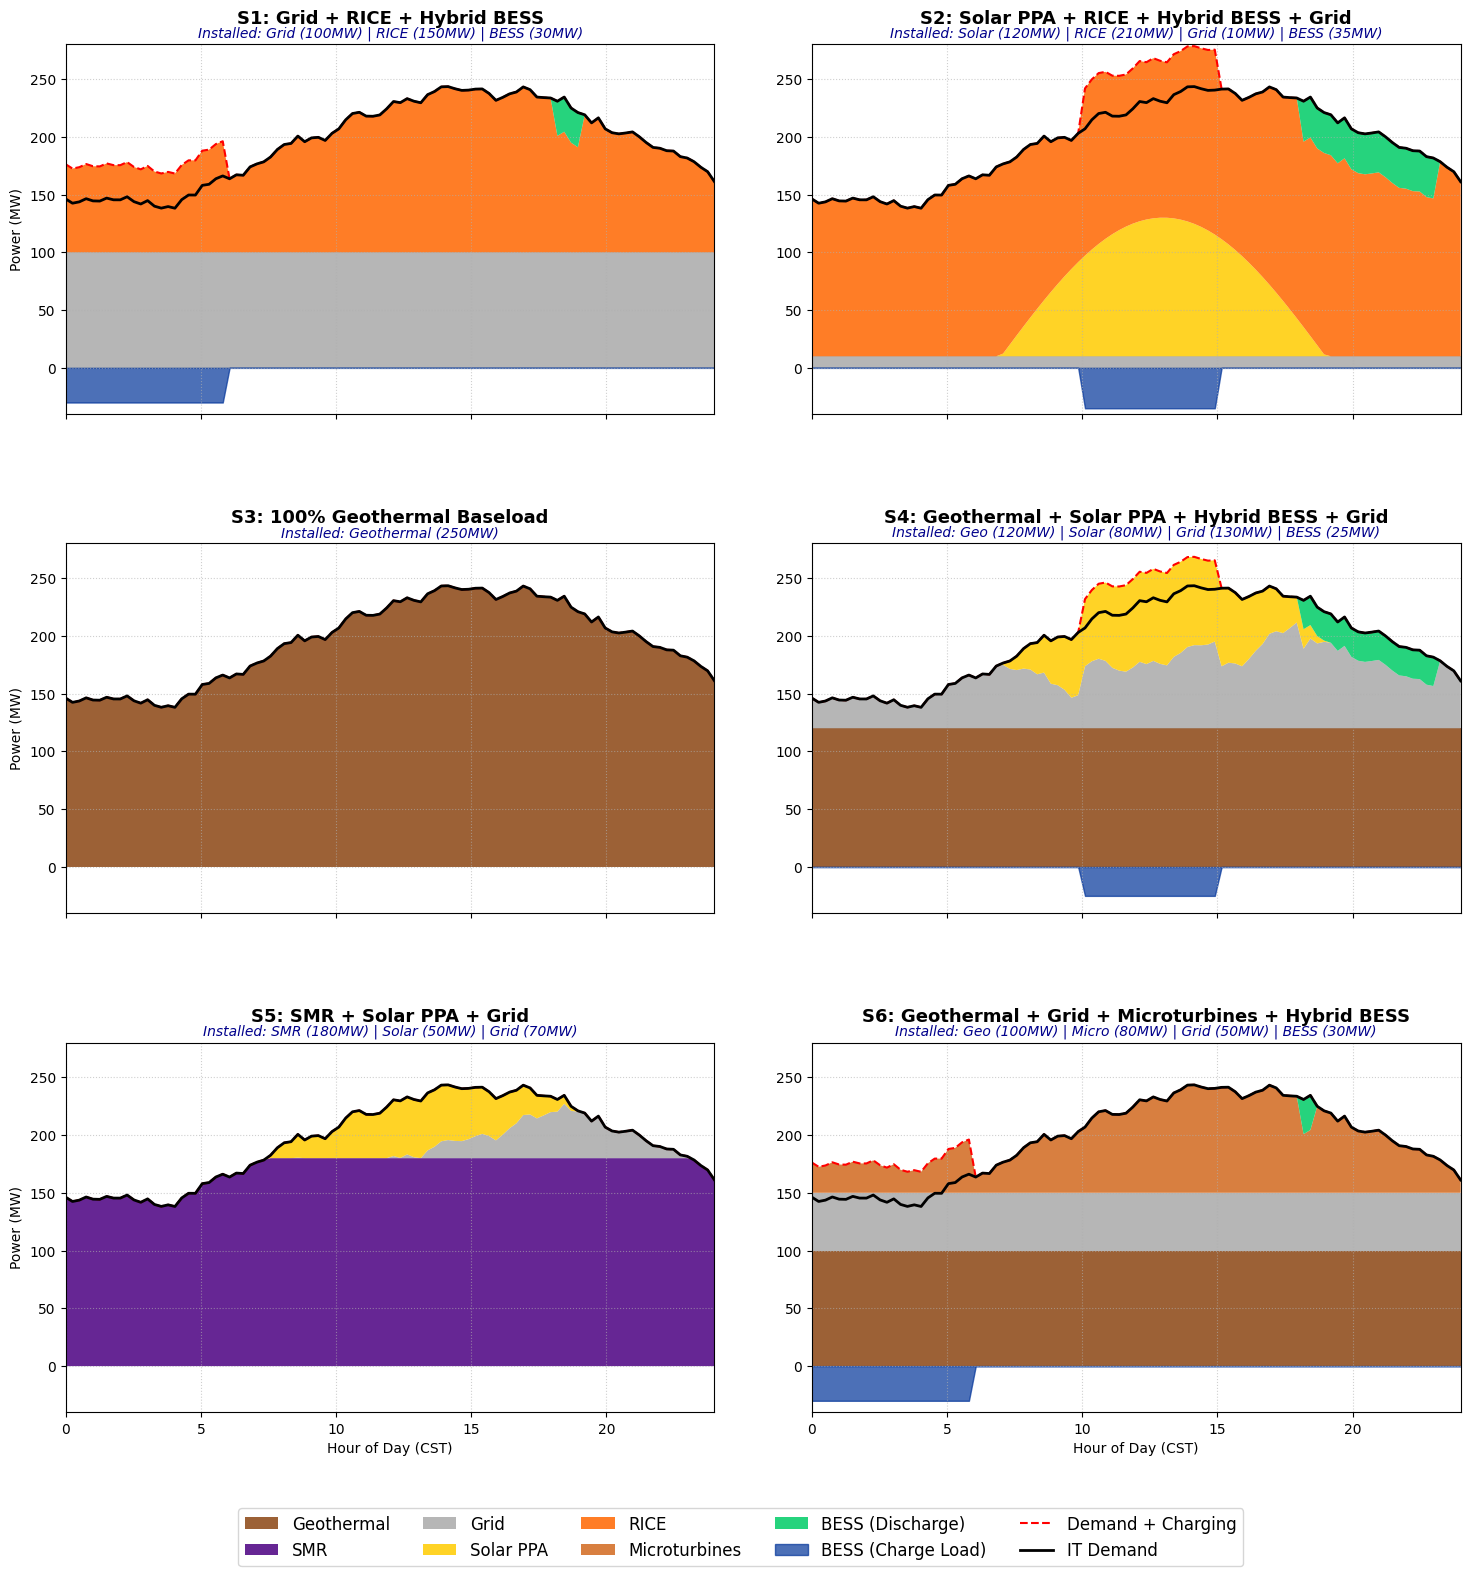

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP & HIGH USAGE DEMAND GENERATION
# ==========================================
np.random.seed(42)
TIME_STEPS = 96
time_hours = np.linspace(0, 24, TIME_STEPS)
MAX_POWER = 250

# High Usage (Spike) Base Curve
mean_u = 0.7 + 0.25 * np.sin(np.pi * (time_hours - 8) / 14)
noise = np.random.normal(0, 0.05, TIME_STEPS)
smoothed_noise = pd.Series(noise).rolling(window=4, min_periods=1).mean().values
u_sim = np.clip(mean_u + smoothed_noise, 0.1, 1.0)

PUE = 1.2
IDLE_FRACTION = 0.20
max_it_power = MAX_POWER / PUE
base_it_power = max_it_power * IDLE_FRACTION
demand_mw = (base_it_power + (max_it_power - base_it_power) * u_sim) * PUE
demand_mw = np.clip(demand_mw, 0, MAX_POWER)

solar_curve = np.zeros(TIME_STEPS)
daylight = (time_hours >= 7) & (time_hours <= 19)
solar_curve[daylight] = np.sin(np.pi * (time_hours[daylight] - 7) / 12)

charging_hours_night = (time_hours >= 0) & (time_hours <= 6)
charging_hours_solar = (time_hours >= 10) & (time_hours <= 15)
evening_peak = (time_hours >= 18) & (time_hours <= 23)

# ==========================================
# 2. DISPATCH LOGIC FOR SCENARIOS
# ==========================================
dispatch_data = {}

# Capacities definition for subtitles
capacities_text = {
    'S1: Grid + RICE + Hybrid BESS': 'Installed: Grid (100MW) | RICE (150MW) | BESS (30MW)',
    'S2: Solar PPA + RICE + Hybrid BESS + Grid': 'Installed: Solar (120MW) | RICE (210MW) | Grid (10MW) | BESS (35MW)',
    'S3: 100% Geothermal Baseload': 'Installed: Geothermal (250MW)',
    'S4: Geothermal + Solar PPA + Hybrid BESS + Grid': 'Installed: Geo (120MW) | Solar (80MW) | Grid (130MW) | BESS (25MW)',
    'S5: SMR + Solar PPA + Grid': 'Installed: SMR (180MW) | Solar (50MW) | Grid (70MW)',
    'S6: Geothermal + Grid + Microturbines + Hybrid BESS': 'Installed: Geo (100MW) | Micro (80MW) | Grid (50MW) | BESS (30MW)'
}

# S1
s1_bess_charge = np.where(charging_hours_night, 30, 0)
s1_eff_demand = demand_mw + s1_bess_charge
s1_grid = np.minimum(s1_eff_demand, 100)
s1_remainder = s1_eff_demand - s1_grid
s1_bess_discharge = np.where(evening_peak & (demand_mw > 220), 30, 0)
s1_rice = s1_remainder - s1_bess_discharge

dispatch_data['S1: Grid + RICE + Hybrid BESS'] = {
    'Grid': s1_grid, 'RICE': s1_rice, 'BESS (Discharge)': s1_bess_discharge,
    'Solar PPA': np.zeros(TIME_STEPS), 'Geothermal': np.zeros(TIME_STEPS),
    'SMR': np.zeros(TIME_STEPS), 'Microturbines': np.zeros(TIME_STEPS),
    'BESS (Charge)': s1_bess_charge
}

# S2
s2_solar_gen = solar_curve * 120
s2_bess_charge = np.where(charging_hours_solar, 35, 0)
s2_eff_demand = demand_mw + s2_bess_charge
s2_solar_used = np.minimum(s2_eff_demand, s2_solar_gen)
s2_grid = np.minimum(s2_eff_demand - s2_solar_used, 10)
s2_remainder = s2_eff_demand - s2_solar_used - s2_grid
s2_bess_discharge = np.where(evening_peak & (s2_remainder > 150), 35, 0)
s2_rice = np.maximum(s2_remainder - s2_bess_discharge, 0)

dispatch_data['S2: Solar PPA + RICE + Hybrid BESS + Grid'] = {
    'Grid': s2_grid, 'RICE': s2_rice, 'BESS (Discharge)': s2_bess_discharge, 'Solar PPA': s2_solar_used,
    'Geothermal': np.zeros(TIME_STEPS), 'SMR': np.zeros(TIME_STEPS), 'Microturbines': np.zeros(TIME_STEPS),
    'BESS (Charge)': s2_bess_charge
}

# S3
dispatch_data['S3: 100% Geothermal Baseload'] = {
    'Grid': np.zeros(TIME_STEPS), 'RICE': np.zeros(TIME_STEPS), 'BESS (Discharge)': np.zeros(TIME_STEPS),
    'Solar PPA': np.zeros(TIME_STEPS), 'Geothermal': demand_mw, 'SMR': np.zeros(TIME_STEPS), 'Microturbines': np.zeros(TIME_STEPS),
    'BESS (Charge)': np.zeros(TIME_STEPS)
}

# S4
s4_geo = np.minimum(demand_mw, 120)
s4_solar_gen = solar_curve * 80
s4_bess_charge = np.where(charging_hours_solar, 25, 0)
s4_eff_demand = demand_mw + s4_bess_charge
s4_solar_used = np.minimum(s4_eff_demand - s4_geo, s4_solar_gen)
s4_solar_used = np.maximum(s4_solar_used, 0)
s4_remainder = s4_eff_demand - s4_geo - s4_solar_used
s4_bess_discharge = np.where(evening_peak & (s4_remainder > 50), 25, 0)
s4_grid = np.maximum(s4_remainder - s4_bess_discharge, 0)

dispatch_data['S4: Geothermal + Solar PPA + Hybrid BESS + Grid'] = {
    'Grid': s4_grid, 'RICE': np.zeros(TIME_STEPS), 'BESS (Discharge)': s4_bess_discharge, 'Solar PPA': s4_solar_used,
    'Geothermal': s4_geo, 'SMR': np.zeros(TIME_STEPS), 'Microturbines': np.zeros(TIME_STEPS),
    'BESS (Charge)': s4_bess_charge
}

# S5
s5_smr = np.minimum(demand_mw, 180)
s5_remainder = demand_mw - s5_smr
s5_solar_used = np.minimum(s5_remainder, solar_curve * 50)
s5_grid = s5_remainder - s5_solar_used
dispatch_data['S5: SMR + Solar PPA + Grid'] = {
    'Grid': s5_grid, 'RICE': np.zeros(TIME_STEPS), 'BESS (Discharge)': np.zeros(TIME_STEPS), 'Solar PPA': s5_solar_used,
    'Geothermal': np.zeros(TIME_STEPS), 'SMR': s5_smr, 'Microturbines': np.zeros(TIME_STEPS),
    'BESS (Charge)': np.zeros(TIME_STEPS)
}

# S6
s6_geo = np.minimum(demand_mw, 100)
s6_bess_charge = np.where(charging_hours_night, 30, 0)
s6_eff_demand = demand_mw + s6_bess_charge
s6_grid = np.minimum(s6_eff_demand - s6_geo, 50)
s6_remainder = s6_eff_demand - s6_geo - s6_grid
s6_bess_discharge = np.where(evening_peak & (s6_remainder > 80), 30, 0)
s6_micro = np.maximum(s6_remainder - s6_bess_discharge, 0)

dispatch_data['S6: Geothermal + Grid + Microturbines + Hybrid BESS'] = {
    'Grid': s6_grid, 'RICE': np.zeros(TIME_STEPS), 'BESS (Discharge)': s6_bess_discharge, 'Solar PPA': np.zeros(TIME_STEPS),
    'Geothermal': s6_geo, 'SMR': np.zeros(TIME_STEPS), 'Microturbines': s6_micro,
    'BESS (Charge)': s6_bess_charge
}

# ==========================================
# 3. PLOTTING THE 2x3 GRID
# ==========================================
fig, axes = plt.subplots(3, 2, figsize=(18, 18), sharex=True)
plt.subplots_adjust(hspace=0.35, wspace=0.15)
axes = axes.flatten()

colors = {
    'Grid': '#aaaaaa',
    'Geothermal': '#8b4513',
    'SMR': '#4b0082',
    'Solar PPA': '#ffcc00',
    'RICE': '#ff6600',
    'Microturbines': '#d2691e',
    'BESS (Discharge)': '#00cc66'
}
sources = ['Geothermal', 'SMR', 'Grid', 'Solar PPA', 'RICE', 'Microturbines', 'BESS (Discharge)']

for idx, (title, data) in enumerate(dispatch_data.items()):
    ax = axes[idx]
    y_stack = [data[source] for source in sources]

    # Generation Stack
    ax.stackplot(time_hours, y_stack, labels=sources, colors=[colors[s] for s in sources], alpha=0.85)

    # BESS Charging (Negative Load)
    bess_charge = data['BESS (Charge)']
    if np.max(bess_charge) > 0:
        ax.fill_between(time_hours, 0, -bess_charge, color='#003399', alpha=0.7, label='BESS (Charge Load)')

    # Effective Demand
    eff_demand = demand_mw + bess_charge
    ax.plot(time_hours, eff_demand, color='red', linestyle='--', linewidth=1.5, label='Demand + Charging')

    # IT Demand
    ax.plot(time_hours, demand_mw, color='black', linewidth=2, label='IT Demand')

    # Titles and Subtitles
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    # Add the capacity subtitle
    cap_text = capacities_text[title]
    ax.text(0.5, 1.01, cap_text, transform=ax.transAxes, ha='center', va='bottom', fontsize=10, color='darkblue', style='italic')

    if idx % 2 == 0:
        ax.set_ylabel('Power (MW)')
    ax.set_xlim(0, 24)
    ax.set_ylim(-40, 280)
    ax.grid(True, linestyle=':', alpha=0.6)

    if idx >= 4:
        ax.set_xlabel('Hour of Day (CST)')

# Create a single master legend at the bottom of the figure
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='lower center', bbox_to_anchor=(0.5, 0.03), ncol=5, fontsize=12)

# Adjust layout to make room for legend
plt.subplots_adjust(bottom=0.12)

plt.savefig('generation_dispatch_phase3_grid_capacities.png', dpi=300, bbox_inches='tight')